In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

pd.set_option('display.max_columns', None)

In [2]:
returns_df = pd.read_csv(
    "../data/processed/nav_daily_returns.csv"
)

returns_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
print(returns_df.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


In [4]:
returns_df = returns_df.dropna(subset=['daily_return'])

returns_df.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [7]:
var_cvar_report = (
    returns_df
    .groupby('amfi_code')['daily_return']
    .agg(
        VaR_95=lambda x: x.quantile(0.05),
        CVaR_95=lambda x: x[x <= x.quantile(0.05)].mean()
    )
    .reset_index()
)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
print(var_cvar_report.columns.tolist())

['amfi_code', 'VaR_95', 'CVaR_95']


In [9]:
var_cvar_report.sort_values(
    by='VaR_95'
).head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [10]:
var_cvar_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully")

var_cvar_report.csv saved successfully


In [11]:
scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio_x,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_ratio_y,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,0.95,0.98,1.57,16.0,-19.50,35012,1.45,5,Moderately High,11.0,1.307,2.0,3.5,22.0,21.0,9.90
1,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,1.00,0.80,1.18,19.0,-32.38,28996,1.38,5,High,15.0,0.998,11.0,16.0,17.0,3.0,13.30
2,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High,8.0,1.180,5.0,29.5,15.0,18.0,13.60
3,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate,17.0,1.448,1.0,12.0,23.0,26.0,13.80
4,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,1.0,0.945,14.0,20.0,21.0,33.0,14.25


In [12]:
print(scorecard.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio_x', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'return_rank', 'sharpe_ratio_y', 'sharpe_rank', 'alpha_rank', 'expense_rank', 'drawdown_rank', 'fund_score']


In [13]:
top5_funds = scorecard.sort_values(
    by="sharpe_ratio_x",
    ascending=False
)[["amfi_code","scheme_name","sharpe_ratio_x"]].head(5)

top5_funds

,amfi_code,scheme_name,sharpe_ratio_x
24,120507,ICICI Pru Liquid Fund - Regular - Growth,7.68
34,120844,Kotak Liquid Fund - Regular - Growth,6.18
39,101208,ABSL Liquid Fund - Regular - Growth,5.14
30,100025,HDFC Short Term Debt Fund - Regular - Growth,1.84
37,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52


In [14]:
top_codes = top5_funds["amfi_code"].tolist()

top_returns = returns_df[
    returns_df["amfi_code"].isin(top_codes)
].copy()

top_returns["date"] = pd.to_datetime(top_returns["date"])

top_returns = top_returns.sort_values(
    ["amfi_code", "date"]
)

In [15]:
top_returns["rolling_sharpe"] = (
    top_returns.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: (
            x.rolling(90).mean()
            / x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

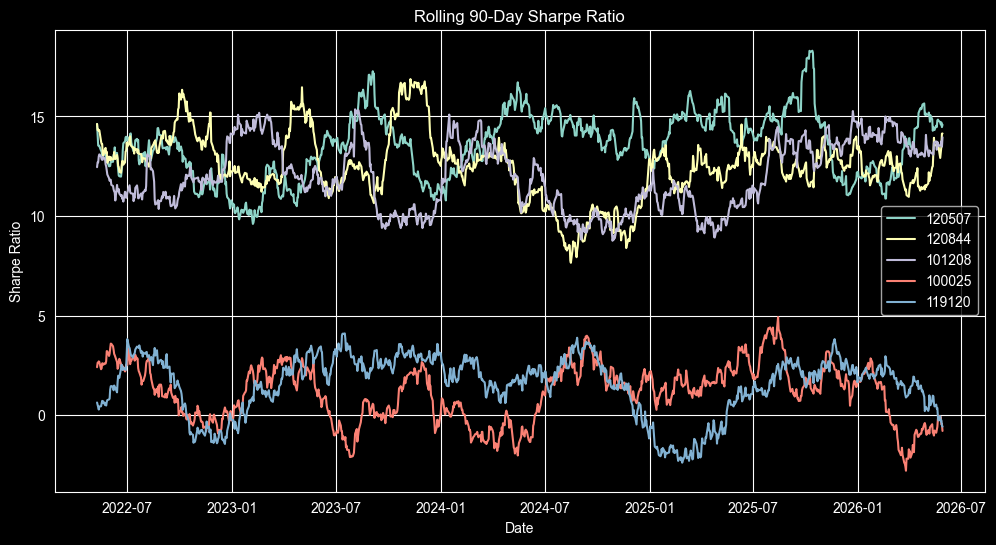

In [16]:
plt.figure(figsize=(12,6))

for code in top_codes:
    fund_data = top_returns[
        top_returns["amfi_code"] == code
    ]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.show()

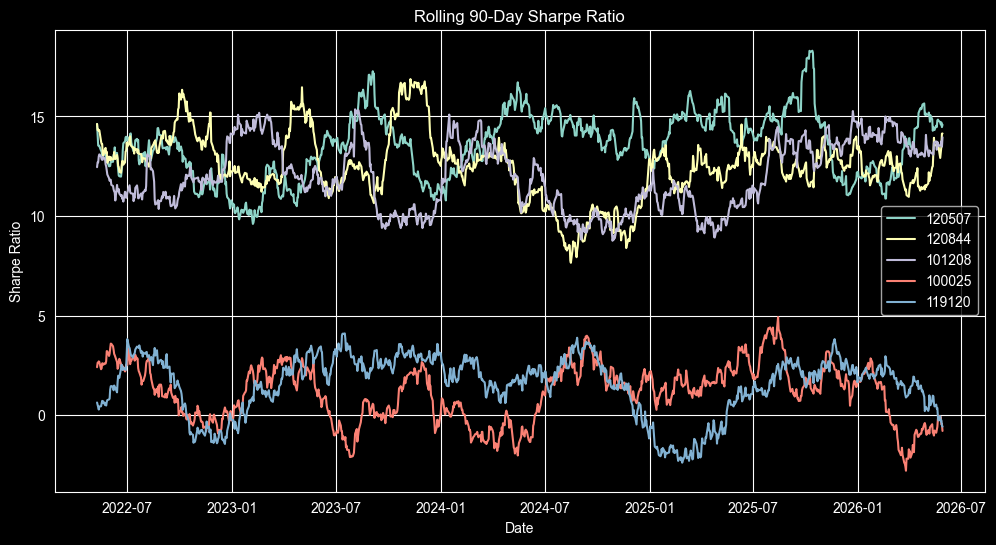

In [17]:
plt.figure(figsize=(12,6))

for code in top_codes:
    fund_data = top_returns[
        top_returns["amfi_code"] == code
    ]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [19]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [20]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

cohort_df = transactions.copy()

cohort_df["cohort_year"] = (
    cohort_df.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

cohort_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [21]:
cohort_summary = (
    cohort_df.groupby("cohort_year")
    .agg(
        avg_investment=("amount_inr", "mean"),
        total_investment=("amount_inr", "sum"),
        investor_count=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_investment,total_investment,investor_count
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [22]:
top_funds = (
    cohort_df.groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="transactions")
)

top_funds = top_funds.sort_values(
    ["cohort_year", "transactions"],
    ascending=[True, False]
)

top_fund_per_cohort = (
    top_funds.groupby("cohort_year")
    .head(1)
)

top_fund_per_cohort

,cohort_year,amfi_code,transactions
35,2024,148568,874
62,2025,119599,12


In [23]:
cohort_report = cohort_summary.merge(
    top_fund_per_cohort[
        ["cohort_year", "amfi_code"]
    ],
    on="cohort_year"
)

cohort_report

,cohort_year,avg_investment,total_investment,investor_count,amfi_code
0,2024,107422.541832,3491125187,4803,148568
1,2025,109158.577061,30455243,197,119599


In [24]:
sip_txns = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

print(sip_txns.shape)
sip_txns.head()

(19716, 13)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


In [25]:
sip_txns["transaction_date"] = pd.to_datetime(
    sip_txns["transaction_date"]
)

sip_txns = sip_txns.sort_values(
    ["investor_id", "transaction_date"]
)

sip_txns.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified


In [26]:
sip_txns.groupby("investor_id").size()\
    .sort_values(ascending=False)\
    .head(10)

investor_id
INV004154    12
INV000612    11
INV004427    11
INV001673    11
INV000676    11
INV001753    11
INV004289    11
INV003650    11
INV002712    11
INV004410    11
dtype: int64

In [27]:
sip_txns["gap_days"] = (
    sip_txns.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_txns.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,gap_days
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,NaN
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,76.0
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,NaN
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,176.0
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,238.0


In [28]:
sip_gap_report = (
    sip_txns.groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

sip_gap_report.head()

,investor_id,sip_count,avg_gap_days
0,INV000001,2,76.0
1,INV000002,3,207.0
2,INV000003,2,238.0
3,INV000004,6,85.4
4,INV000005,3,14.0


In [29]:
sip_gap_report = sip_gap_report[
    sip_gap_report["sip_count"] >= 6
]

sip_gap_report.head()

,investor_id,sip_count,avg_gap_days
3,INV000004,6,85.400000
7,INV000008,6,70.400000
9,INV000010,6,64.800000
10,INV000011,7,40.166667
11,INV000012,8,57.000000


In [30]:
sip_gap_report["status"] = np.where(
    sip_gap_report["avg_gap_days"] > 35,
    "At Risk",
    "Active"
)

sip_gap_report.head()

,investor_id,sip_count,avg_gap_days,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


In [31]:
sip_gap_report["status"].value_counts()

status
At Risk    1332
Active       30
Name: count, dtype: int64

In [32]:
sip_gap_report.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

In [33]:
scorecard["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [34]:
def recommend_funds(risk_level):

    recommendations = (
        scorecard[scorecard["risk_grade"] == risk_level]
        .sort_values(by="sharpe_ratio_x", ascending=False)
        [["scheme_name", "risk_grade", "sharpe_ratio_x", "fund_score"]]
        .head(3)
    )

    return recommendations


for risk in ["Low", "Moderate", "High"]:
    print(f"\nTop Funds for {risk} Risk Investors")
    print("=" * 50)
    print(recommend_funds(risk))


Top Funds for Low Risk Investors
                                 scheme_name risk_grade  sharpe_ratio_x  \
24  ICICI Pru Liquid Fund - Regular - Growth        Low            7.68   
34      Kotak Liquid Fund - Regular - Growth        Low            6.18   
39       ABSL Liquid Fund - Regular - Growth        Low            5.14   

    fund_score  
24       21.80  
34       26.45  
39       31.55  

Top Funds for Moderate Risk Investors
                                      scheme_name risk_grade  sharpe_ratio_x  \
3   Mirae Asset Large Cap Fund - Regular - Growth   Moderate            1.06   
36      HDFC Top 100 Fund - Regular Plan - Growth   Moderate            1.06   
12      ICICI Pru Bluechip Fund - Direct - Growth   Moderate            1.03   

    fund_score  
3       13.800  
36      27.750  
12      17.275  

Top Funds for High Risk Investors
                                      scheme_name risk_grade  sharpe_ratio_x  \
10  Kotak Emerging Equity Fund - Regular - Growth     

In [35]:
scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio_x,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_ratio_y,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,0.95,0.98,1.57,16.0,-19.50,35012,1.45,5,Moderately High,11.0,1.307,2.0,3.5,22.0,21.0,9.90
1,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,1.00,0.80,1.18,19.0,-32.38,28996,1.38,5,High,15.0,0.998,11.0,16.0,17.0,3.0,13.30
2,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High,8.0,1.180,5.0,29.5,15.0,18.0,13.60
3,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate,17.0,1.448,1.0,12.0,23.0,26.0,13.80
4,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,1.0,0.945,14.0,20.0,21.0,33.0,14.25


In [36]:
scorecard.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio_x',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade',
 'return_rank',
 'sharpe_ratio_y',
 'sharpe_rank',
 'alpha_rank',
 'expense_rank',
 'drawdown_rank',
 'fund_score']

In [37]:
def recommend_funds(risk_level):

    recommendations = (
        scorecard[scorecard["risk_grade"] == risk_level]
        .sort_values(by="sharpe_ratio_x", ascending=False)
        [["scheme_name", "risk_grade", "sharpe_ratio_x", "fund_score"]]
        .head(3)
    )

    return recommendations


for risk in ["Low", "Moderate", "High"]:
    print(f"\nTop Funds for {risk} Risk Investors")
    print("=" * 50)
    print(recommend_funds(risk))


Top Funds for Low Risk Investors
                                 scheme_name risk_grade  sharpe_ratio_x  \
24  ICICI Pru Liquid Fund - Regular - Growth        Low            7.68   
34      Kotak Liquid Fund - Regular - Growth        Low            6.18   
39       ABSL Liquid Fund - Regular - Growth        Low            5.14   

    fund_score  
24       21.80  
34       26.45  
39       31.55  

Top Funds for Moderate Risk Investors
                                      scheme_name risk_grade  sharpe_ratio_x  \
3   Mirae Asset Large Cap Fund - Regular - Growth   Moderate            1.06   
36      HDFC Top 100 Fund - Regular Plan - Growth   Moderate            1.06   
12      ICICI Pru Bluechip Fund - Direct - Growth   Moderate            1.03   

    fund_score  
3       13.800  
36      27.750  
12      17.275  

Top Funds for High Risk Investors
                                      scheme_name risk_grade  sharpe_ratio_x  \
10  Kotak Emerging Equity Fund - Regular - Growth     

In [38]:
holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [39]:
hhi_report = (
    holdings.groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x / 100) ** 2).sum())
    .reset_index(name="HHI")
)

hhi_report.sort_values(
    by="HHI",
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [40]:
hhi_report.to_csv(
    "../reports/hhi_concentration_report.csv",
    index=False
)

# Advanced Insights

### 1. Downside Risk Analysis
Historical VaR and CVaR analysis identified the most vulnerable mutual funds based on extreme negative daily returns. Certain funds exhibited significantly higher tail risk than the portfolio average.

### 2. Risk-Adjusted Performance
Rolling 90-Day Sharpe Ratios revealed substantial variation across funds. Liquid and debt-oriented schemes maintained more stable Sharpe ratios, while equity-oriented funds showed higher volatility.

### 3. Investor Cohort Behaviour
The 2024 investor cohort contributed the highest total investment volume and represented the majority of active investors in the dataset.

### 4. SIP Continuity Risk
A large proportion of investors showed average SIP gaps greater than 35 days, indicating elevated discontinuity risk and potential future redemption behaviour.

### 5. Portfolio Concentration
HHI analysis showed that some funds maintain concentrated sector allocations while others are more diversified, highlighting differences in portfolio construction strategies.